In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
sns.set_theme(style='darkgrid', palette='Set2')
plt.rcParams['figure.dpi'] = 150

In [56]:
df = pd.read_csv('amazon_cleaned.csv')
df['date'] = pd.to_datetime(df['date'])
# print("shape: ", df.shape)
# print(df.head())
print(df.columns)

Index(['order_id', 'date', 'status', 'fulfilment', 'sales_channel',
       'ship_service_level', 'style', 'sku', 'category', 'size', 'asin',
       'courier_status', 'qty', 'currency', 'amount', 'ship_city',
       'ship_state', 'ship_postal_code', 'ship_country', 'promotion_ids',
       'b2b', 'fulfilled_by', 'ship_satate', 'revenue', 'month', 'week'],
      dtype='object')


In [10]:
print(df.describe())

                                date            qty         amount  \
count                         121177  121177.000000  121177.000000   
mean   2022-05-12 12:07:59.496934400       0.961230     648.555776   
min              2022-03-31 00:00:00       0.000000       0.000000   
25%              2022-04-20 00:00:00       1.000000     449.000000   
50%              2022-05-10 00:00:00       1.000000     605.000000   
75%              2022-06-04 00:00:00       1.000000     788.000000   
max              2022-06-29 00:00:00       8.000000    5584.000000   
std                              NaN       0.214356     281.209851   

       ship_postal_code        revenue           week  
count     121146.000000  121177.000000  121177.000000  
mean      463657.956276     627.443913      19.070079  
min       110001.000000       0.000000      13.000000  
25%       382421.000000     432.000000      16.000000  
50%       500032.000000     597.000000      19.000000  
75%       600021.000000     777.0

In [13]:
print("\nTotal Revenue: ₹", df['revenue'].sum().round(2))
print("Total Orders: ", len(df))
print("Avg Order Value: ₹", df['amount'].mean().round(2))
print("Date Range: ", df['date'].min(), "to",df['date'].max())


Total Revenue:  76031771.0
Total Orders:  121177
Avg Order Value:  648.56
Date Range:  2022-03-31 00:00:00 to 2022-06-29 00:00:00


In [16]:
print(df.groupby('category')[['revenue','amount']].agg({
    'revenue': 'sum',
    'amount': 'mean'
}).round(2).sort_values('revenue', ascending=False))

                  revenue  amount
category                         
Set            37932332.0  833.38
kurta          20674816.0  455.93
Western Dress  10707932.0  762.79
Top             5242931.0  526.10
Ethnic Dress     762949.0  723.90
Blouse           441259.0  520.33
Bottom           142870.0  358.73
Saree            125767.0  799.57
Dupatta             915.0  305.00


In [17]:
print(df['status'].value_counts())
print("\nCancellation rate: ",round(df['status'].str.contains('Cancelled').sum() / len(df) * 100,2), "%")

status
Shipped                          77593
Shipped - Delivered to Buyer     28761
Cancelled                        10766
Shipped - Returned to Seller      1950
Shipped - Picked Up                973
Pending                            656
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

Cancellation rate:  8.88 %


In [19]:
print(df.groupby('ship_state')['revenue'].sum().sort_values(ascending=False).head(10))

ship_state
MAHARASHTRA       12936412.0
KARNATAKA         10222900.0
TELANGANA          6705327.0
UTTAR PRADESH      6555128.0
TAMIL NADU         6327065.0
DELHI              4092973.0
KERALA             3641375.0
WEST BENGAL        3378962.0
ANDHRA PRADESH     3109687.0
HARYANA            2829354.0
Name: revenue, dtype: float64


In [20]:
print(df['size'].value_counts().head(8))

size
M      21291
L      20800
XL     19725
XXL    17066
S      15953
3XL    14051
XS     10296
6XL      705
Name: count, dtype: int64


In [21]:
print(df.groupby('month')['revenue'].sum())

month
2022-03       98261.0
2022-04    27847245.0
2022-05    25325211.0
2022-06    22761054.0
Name: revenue, dtype: float64


In [22]:
print(df.groupby('b2b')['revenue'].sum())

b2b
False    75414591.0
True       617180.0
Name: revenue, dtype: float64


In [23]:
print(df.groupby('fulfilment')['revenue'].sum())

fulfilment
Amazon      54711512.0
Merchant    21320259.0
Name: revenue, dtype: float64


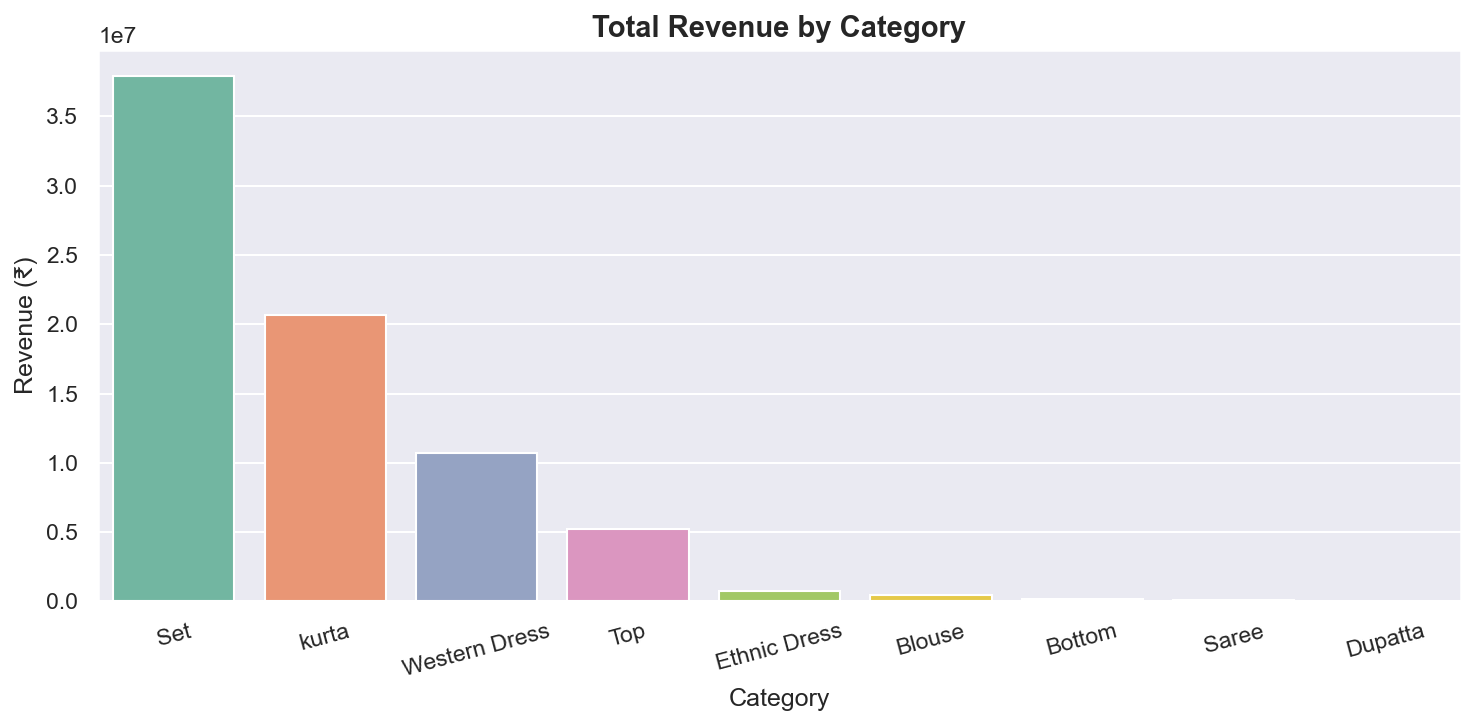

Chart 1 saved


In [28]:
cat_rev = (df.groupby('category')['revenue']
        .sum()
        .reset_index()
        .sort_values('revenue', ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(data=cat_rev, x='category', y='revenue', palette='Set2')
plt.title('Total Revenue by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('charts_revenue_by_category.png', dpi=150)
plt.show()
print("Chart 1 saved")

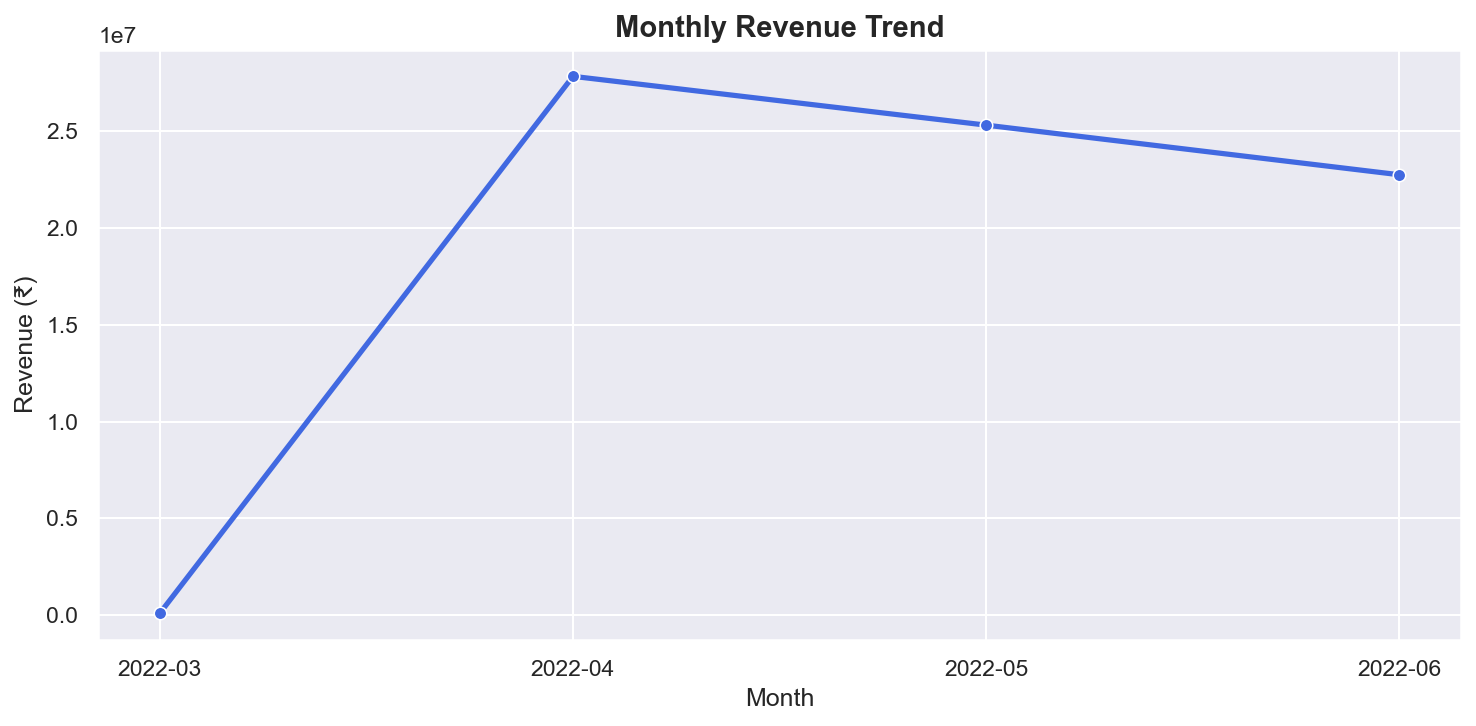

Chart 2 saved


In [30]:
monthly = df.groupby('month')['revenue'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly, x='month', y='revenue', marker='o', linewidth=2.5, color='royalblue')
plt.fill_between(monthly['month'], monthly['revenue'], alpha=0.15, color='royalblue')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.tight_layout()
plt.savefig('chart2_monthly_trend.png', dpi=150)
plt.show()
print("Chart 2 saved")

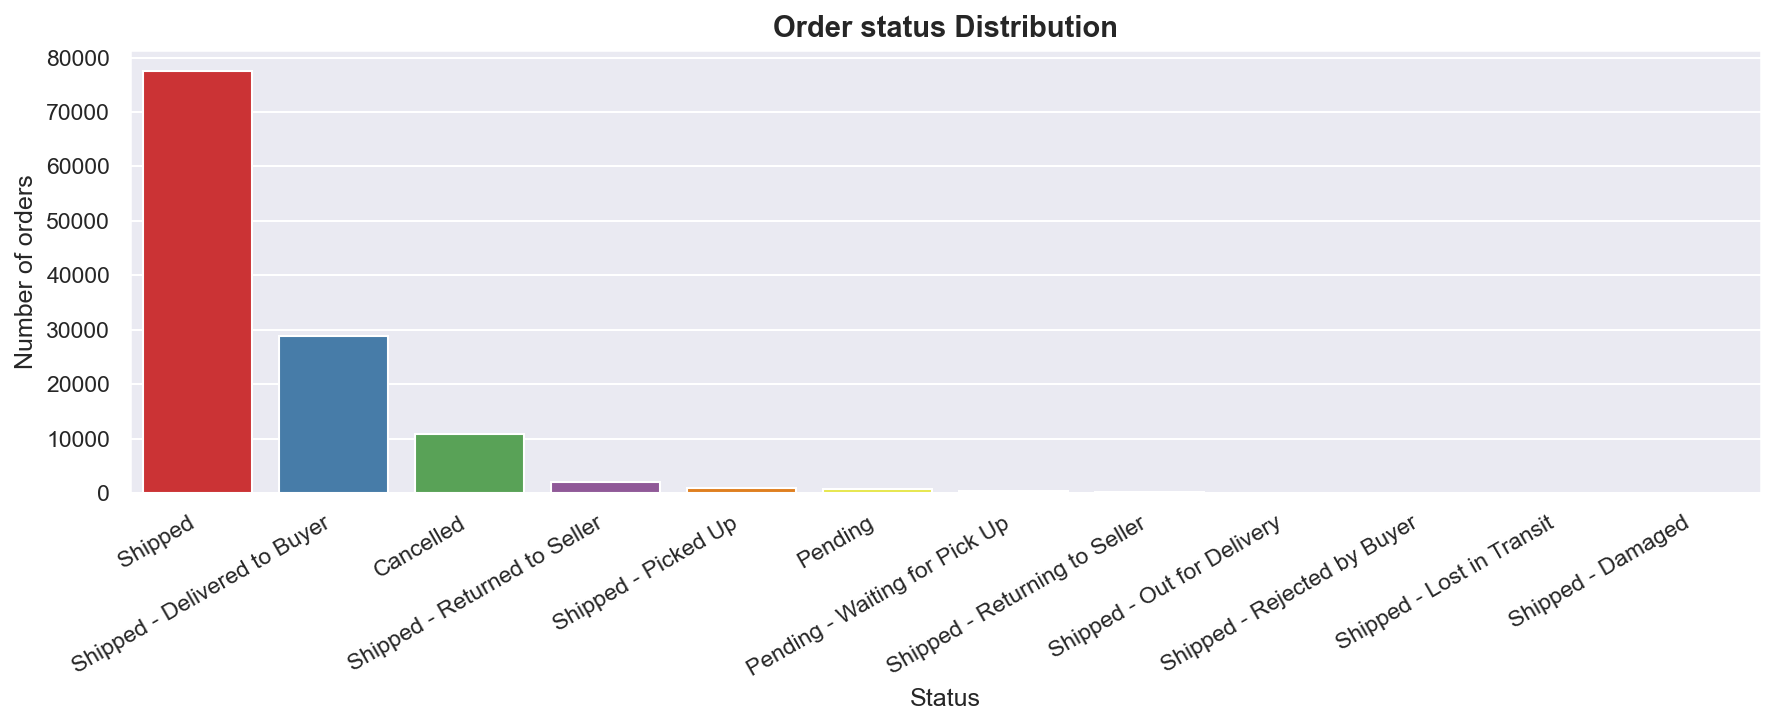

Chart 3 saved


In [33]:
status_df = df['status'].value_counts().reset_index()
status_df.columns = ['status', 'count']

plt.figure(figsize=(12, 5))
sns.barplot(data=status_df, x='status', y='count', palette='Set1')
plt.title('Order status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Status')
plt.ylabel('Number of orders')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart3_order_status.png', dpi=150)
plt.show()
print("Chart 3 saved")

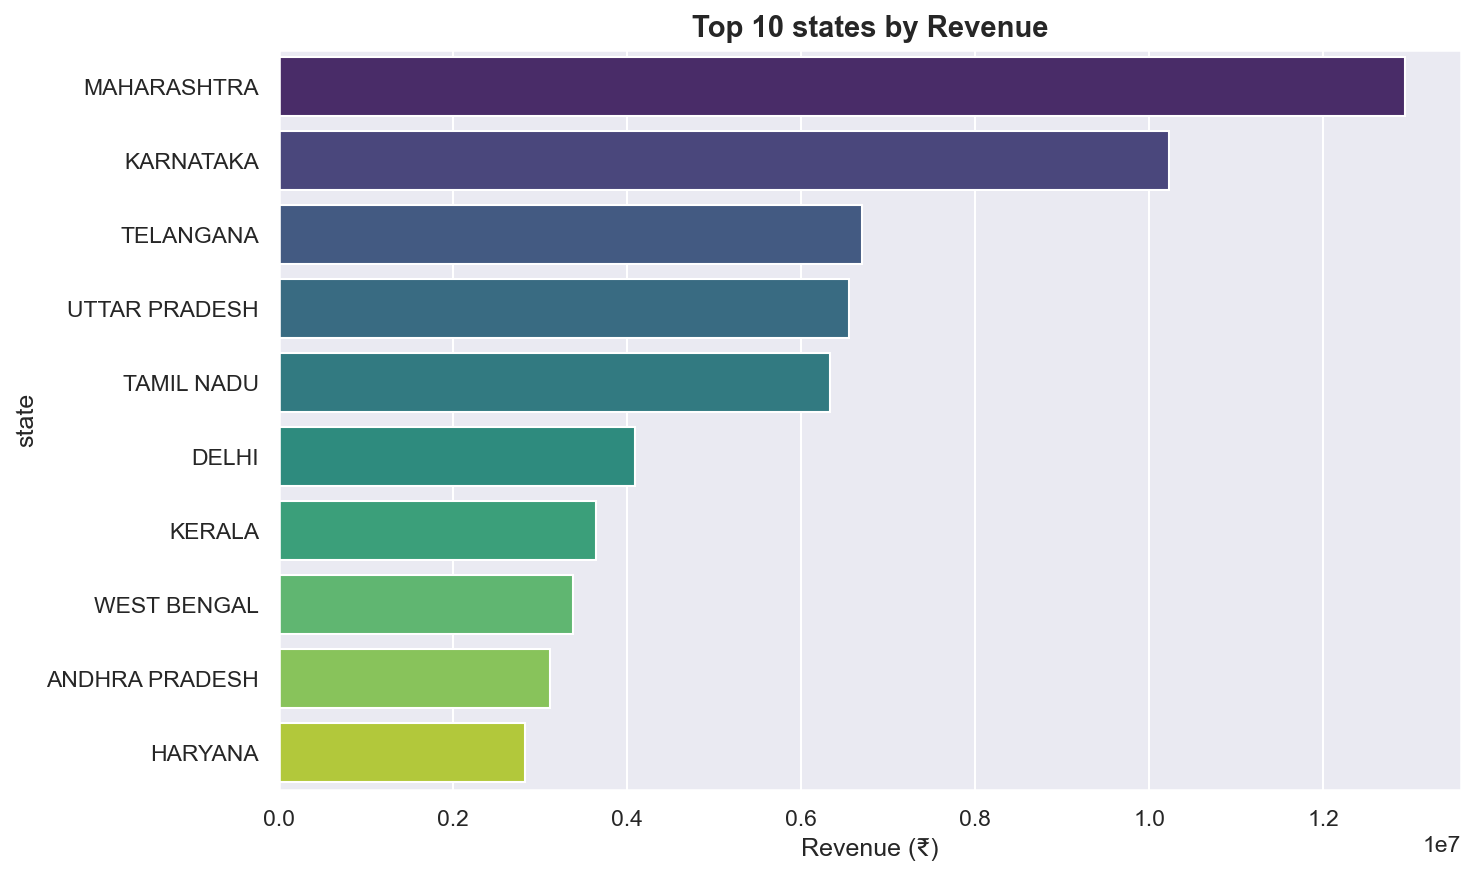

Chart 4 saved


In [38]:
top_states = (df.groupby('ship_state')['revenue']
            .sum()
            .reset_index()
            .sort_values('revenue', ascending=False)
            .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(data=top_states, x='revenue', y='ship_state',palette='viridis', orient='h')
plt.title('Top 10 states by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (₹)')
plt.ylabel('state')
plt.tight_layout()
plt.savefig('chart4_top_states.png', dpi=150)
plt.show()
print('Chart 4 saved')

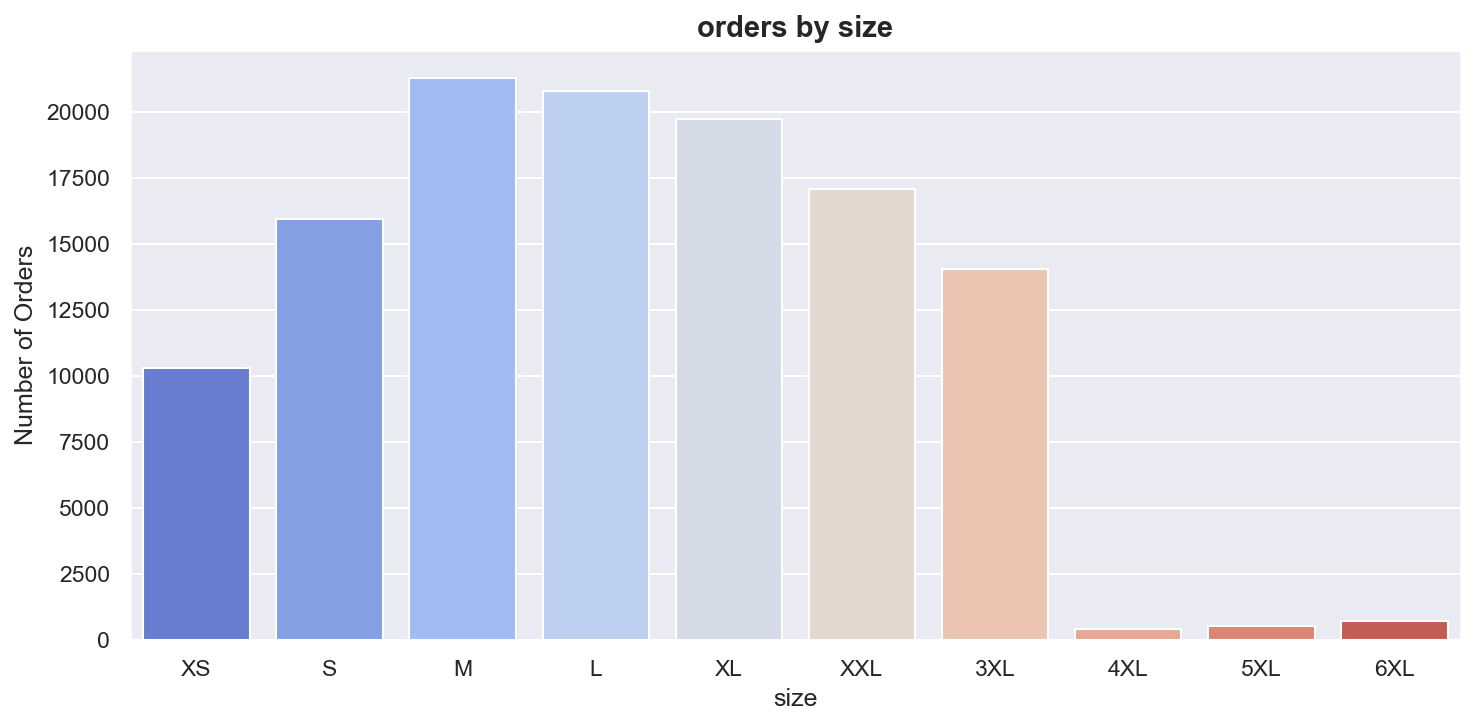

Chart 5 saved


In [41]:
size_order = ['XS','S','M','L','XL','XXL','3XL','4XL','5XL','6XL',]
size_df = (df['size'].value_counts()
            .reindex(size_order)
            .dropna()
           .reset_index()
)
size_df.columns = ['size', 'count']

plt.figure(figsize=(10, 5))
sns.barplot(data=size_df, x='size', y='count', palette='coolwarm')
plt.title('orders by size', fontsize=14, fontweight='bold')
plt.xlabel('size')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('chart5-size_distribution.png', dpi=150)
plt.show()
print("Chart 5 saved")

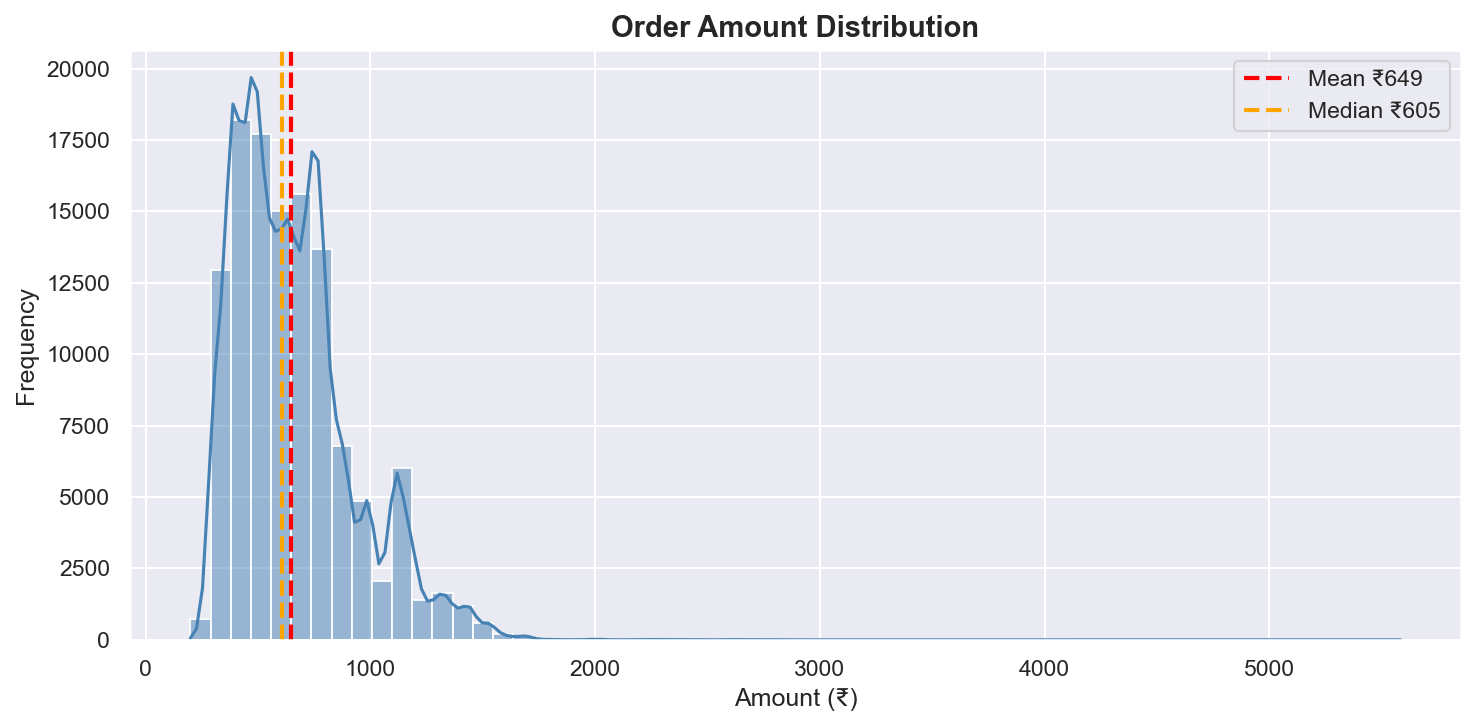

Chart 6 saved


In [46]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df[df['amount'] > 0], x ='amount',
             bins=60, color='steelblue', kde=True)
plt.axvline(df['amount'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean ₹{df['amount'].mean():.0f}")
plt.axvline(df['amount'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median ₹{df['amount'].median():.0f}")
plt.title('Order Amount Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Amount (₹)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('chart6_amount_distribution.png', dpi=150)
plt.show()
print("Chart 6 saved")

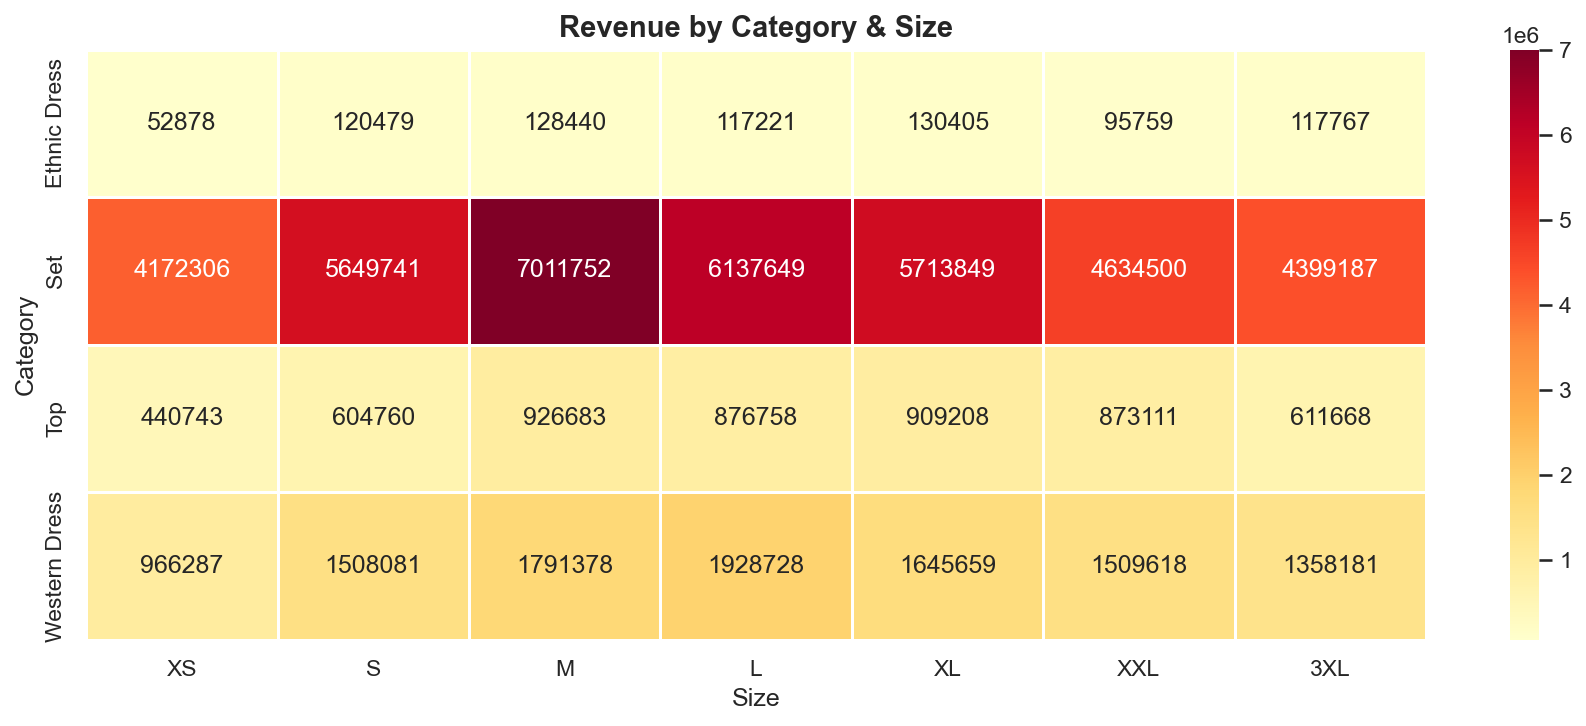

Chart7 saved


In [47]:
size_order = ['XS', 'S', 'M', 'L', 'XL', 'XXL', '3XL']
top_cats = ['Set', 'Kurta', 'Western Dress', 'Top', 'Ethnic Dress']

heatmap_data = (df[df['category'].isin(top_cats) & df['size'].isin(size_order)]
                .groupby(['category', 'size',])['revenue']
                .sum()
                .unstack()
                .reindex(columns=size_order)
)

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Revenue by Category & Size', fontsize=14, fontweight='bold')
plt.xlabel('Size')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('chart7_heatmap_cat_size.png', dpi=150)

plt.show()
print("Chart7 saved")

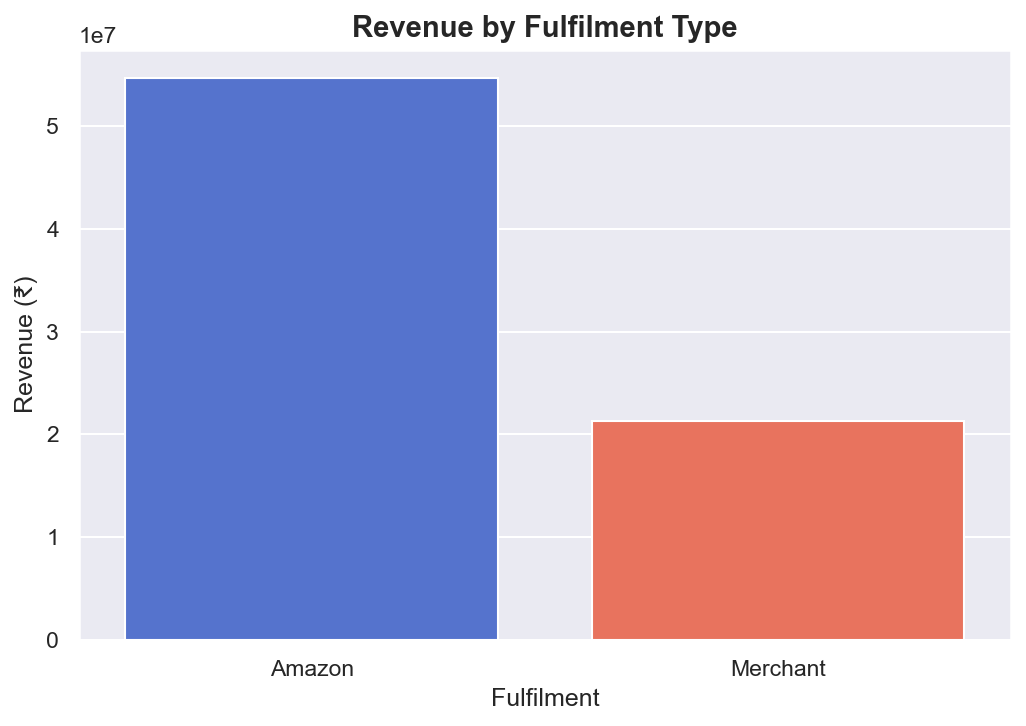

Chart 8 saved


In [50]:
ful_df = df.groupby('fulfilment')['revenue'].sum().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=ful_df, x='fulfilment', y='revenue', palette=['royalblue', 'tomato'])
plt.title('Revenue by Fulfilment Type', fontsize=14, fontweight='bold')
plt.xlabel('Fulfilment')
plt.ylabel('Revenue (₹)')
plt.tight_layout()
plt.savefig('chart8_fulfilment.png', dpi=150)
plt.show()
print("Chart 8 saved")

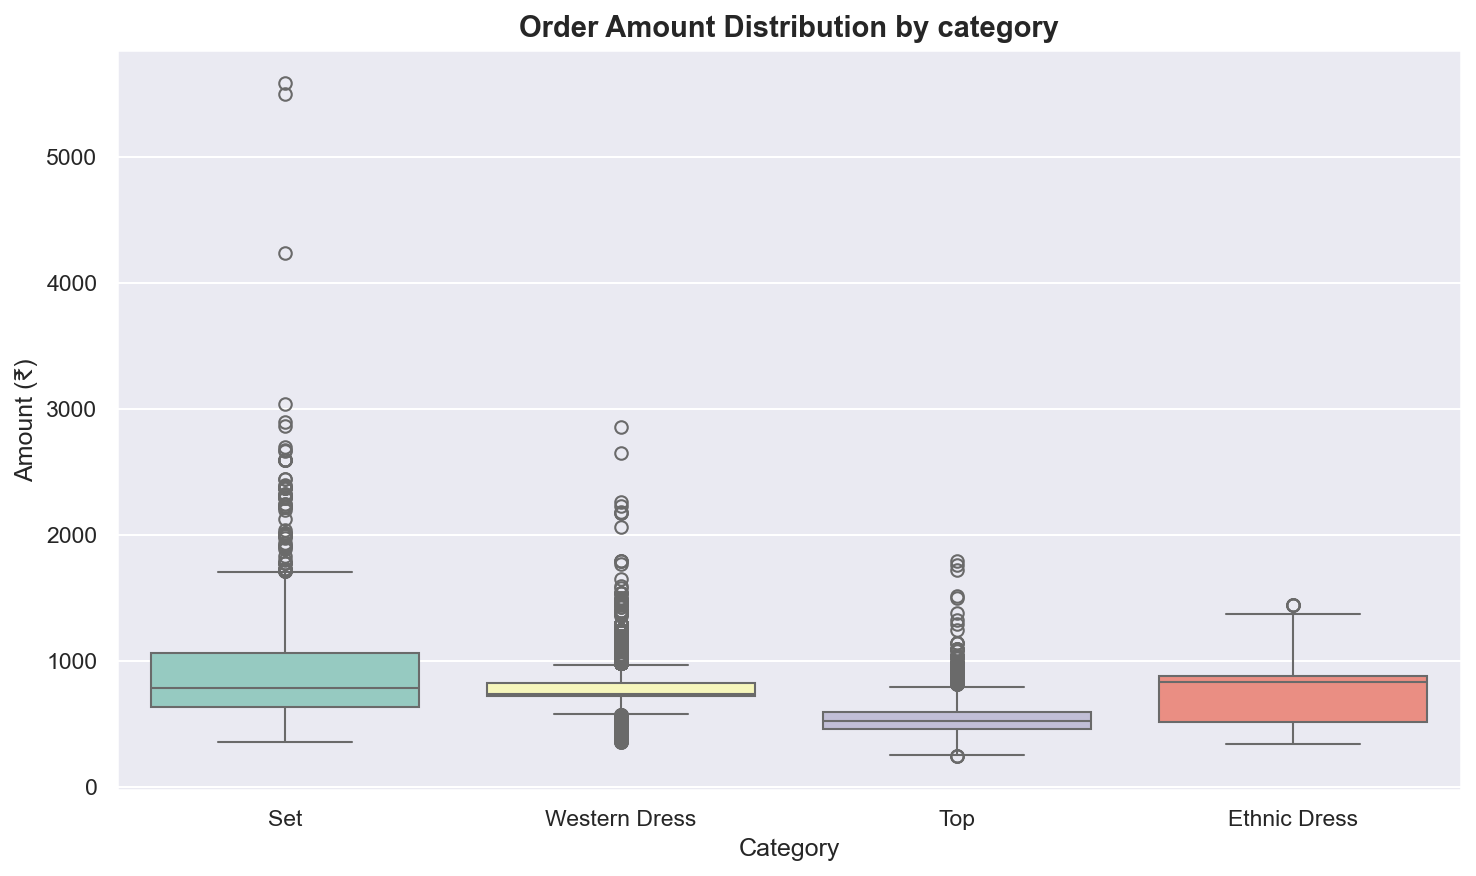

chart 9 saved


In [52]:
top_cats = ['Set', 'Kurta', 'Western Dress', 'Top', 'Ethnic Dress']
df_box = df[df['category'].isin(top_cats) & (df['amount'] > 0)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_box, x='category', y='amount', palette='Set3')
plt.title('Order Amount Distribution by category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Amount (₹)')
plt.tight_layout()
plt.savefig('chart9_boxplot_category.png', dpi=150)
plt.show()
print('chart 9 saved')

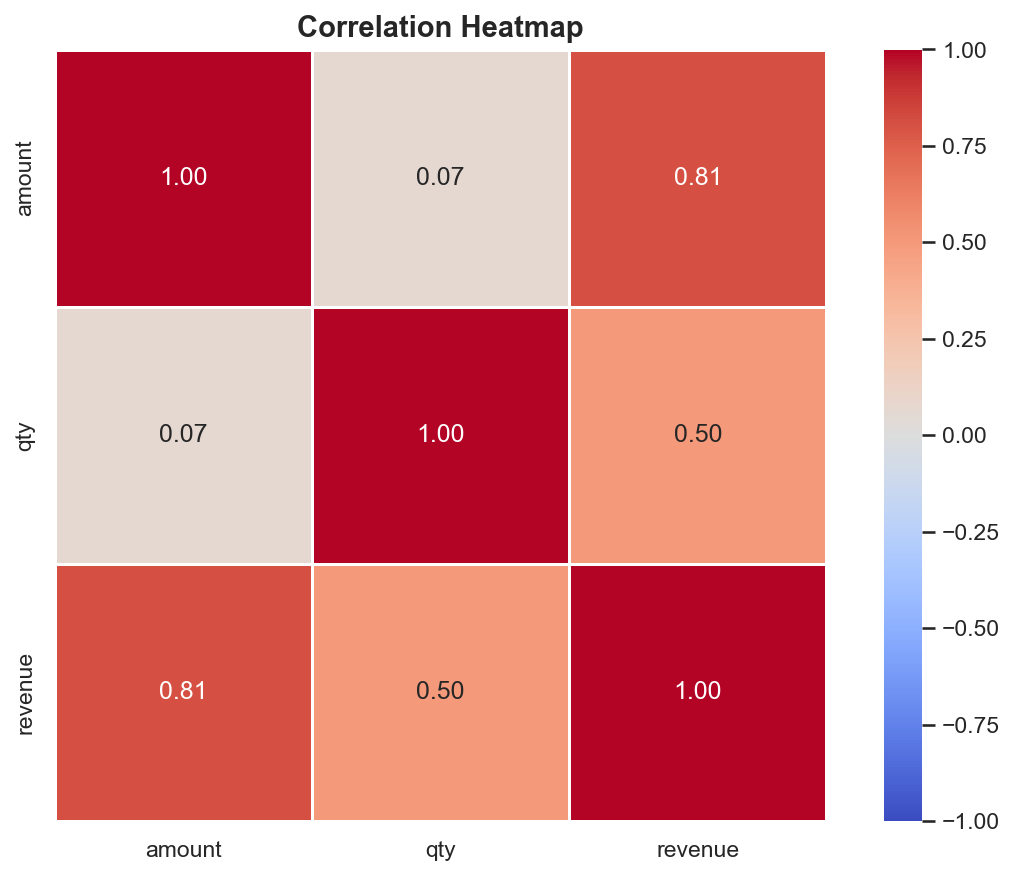

chart 10 saved


In [53]:
plt.figure(figsize=(8, 6))
numeric_cols = df[['amount', 'qty', 'revenue']].corr()
sns.heatmap(numeric_cols, annot=True, fmt='.2f',
            cmap='coolwarm', square=True,
            linewidth=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart10_correlation.png', dpi=150)
plt.show()
print("chart 10 saved")